### Gradient Descent in 2D

In 2D the gradient descent is calcualted using partial derivatives

example:

$\frac{\partial f}{\partial x} = f_x(x)$

Gradient: 

$\bigtriangledown = (\partial_x f, \partial_y f, ..., \partial_z f)$

Lets assume the function:


$f(x, y) = 3(1-x)^2 e^{-x^2-(y+1)^2} -10(\frac{x}{5}-x^3-y^5)e^{-x^2-y^2}-\frac{1}{3}e^{-(x+1)^2-y^2}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sympy as sym

In [9]:
def peaks(x, y):
    x, y = np.meshgrid(x, y)

    z = (
        3*(1-x)**2 * np.exp(-x**2 - (y+1)**2)
        - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2)
        - (1/3) * np.exp(-(x+1)**2 - y**2)
    )
    return z

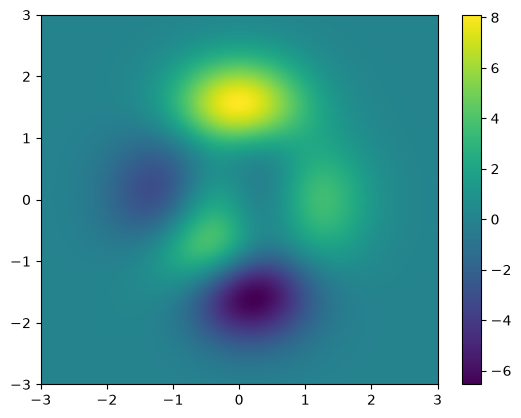

In [11]:
x = np.linspace(-3, 3, 201)
y = np.linspace(-3, 3, 201)

Z = peaks(x,y)


plt.imshow(
    z,
    extent=[x[0], x[-1], y[0], y[-1]],
    origin='lower',
    aspect='auto'
)

plt.colorbar()
plt.show()

In [13]:
sx, sy = sym.symbols('sx, sy')

sz = (
        3*(1-sx)**2 * sym.exp(-sx**2 - (sy+1)**2)
        - 10*(sx/5 - sx**3 - sy**5) * sym.exp(-sx**2 - sy**2)
        - (1/3) * sym.exp(-(sx+1)**2 - sy**2)
    )

df_x = sym.lambdify((sx, sy), sym.diff(sz, sx), 'sympy')
df_y = sym.lambdify((sx, sy), sym.diff(sz, sy), 'sympy')

df_x(1,1).evalf()

-1.07369833656079

### 2D gradient Descent

In [21]:
local_min = np.random.rand(2)

start_point = local_min[:]

lr = 0.01
epochs = 1000

trajectory = np.zeros((epochs, 2))
for i in range(epochs):
    grad = np.array([
        df_x(local_min[0], local_min[1]).evalf(),
        df_y(local_min[0], local_min[1]).evalf(),
    ])
    local_min = local_min - (lr * grad)
    trajectory[i, 0] = local_min[0]
    trajectory[i, 1] = local_min[1]
print(start_point)
print(local_min)

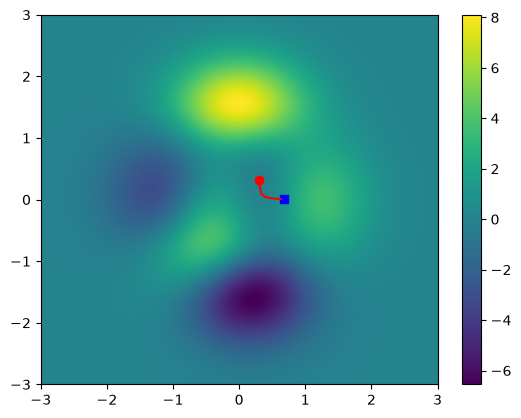

In [22]:
plt.imshow(
    z,
    extent=[x[0], x[-1], y[0], y[-1]],
    origin='lower',
    aspect='auto'
)
plt.plot(start_point[0], start_point[1], 'bs')
plt.plot(local_min[0], local_min[1], 'ro')
plt.plot(trajectory[:,0], trajectory[:,1], 'r')

plt.colorbar()
plt.show()